# Named Entity Recognition with BERT: a model comparison

Named Entity Recognition (NER) is a sequence labelling task: the goal is to identify spans of text referring to real-world entities and assign them a category from a predefined ontology.

BERT handles this as a **token classification** problem. A linear head is placed on top of the final hidden states, one per token, and fine-tuned to predict an entity label. Being bidirectional, BERT already encodes the full sentence context at classification time, giving each token a rich representation before the label is assigned.

All three models were fine-tuned on **CoNLL-2003**, the standard English NER benchmark, which defines four entity types:

| Label | Meaning | Example |
|-------|---------|------|
| PER | Person | *Peter Higgs*, *Tim Berners-Lee* |
| ORG | Organisation | *CERN*, *MIT*, *Oxford University* |
| LOC | Location | *Geneva*, *Switzerland* |
| MISC | Miscellaneous named entity | *Nobel Prize in Physics*, *World Wide Web* |

**Models compared:**

| # | HuggingFace ID | Architecture | Params |
|---|----------------|-------------|--------|
| 1 | [`dslim/bert-base-NER`](https://huggingface.co/dslim/bert-base-NER) | BERT-base-cased | ~110M |
| 2 | [`dbmdz/bert-large-cased-finetuned-conll03-english`](https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english) | BERT-large-cased | ~340M |
| 3 | [`dslim/distilbert-NER`](https://huggingface.co/dslim/distilbert-NER) | DistilBERT-cased | ~66M |

In [17]:
import time
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from transformers import pipeline

warnings.filterwarnings('ignore')

N_TIMING_RUNS = 15

## Step 1 - Input Text

The paragraph below covers a well-known scientific event with a dense and varied mix of entity types. It includes persons with non-English names (*François Englert*), long organisation spans (*European Organization for Nuclear Research*), acronyms (*LHC*, *CERN*), and multi-word miscellaneous entities (*Nobel Prize in Physics*, *World Wide Web*).

All three models will be evaluated on the same text, making their outputs directly comparable.

In [18]:
TEXT = (
    "The Large Hadron Collider (LHC) at CERN, located near Geneva on the border "
    "between Switzerland and France, is the world's largest particle accelerator. "
    "It was built by the European Organization for Nuclear Research in collaboration "
    "with over 10,000 scientists from more than 100 countries. "
    "On 4 July 2012, physicists at CERN announced the discovery of the Higgs boson, "
    "a breakthrough that led Peter Higgs and Fran\u00e7ois Englert to receive "
    "the Nobel Prize in Physics in 2013. "
    "The LHC experiments \u002d ATLAS, CMS, ALICE, and LHCb \u002d are run by international "
    "teams from institutions such as MIT, Caltech, Oxford University, and ETH Zurich. "
    "Tim Berners-Lee, a British scientist at CERN, invented the World Wide Web in 1989 "
    "to facilitate information sharing between researchers across European universities."
)

print(TEXT)
print()
print(f'{len(TEXT.split())} words  |  {len(TEXT)} characters')

The Large Hadron Collider (LHC) at CERN, located near Geneva on the border between Switzerland and France, is the world's largest particle accelerator. It was built by the European Organization for Nuclear Research in collaboration with over 10,000 scientists from more than 100 countries. On 4 July 2012, physicists at CERN announced the discovery of the Higgs boson, a breakthrough that led Peter Higgs and François Englert to receive the Nobel Prize in Physics in 2013. The LHC experiments - ATLAS, CMS, ALICE, and LHCb - are run by international teams from institutions such as MIT, Caltech, Oxford University, and ETH Zurich. Tim Berners-Lee, a British scientist at CERN, invented the World Wide Web in 1989 to facilitate information sharing between researchers across European universities.

125 words  |  796 characters


## Step 2 - Model Loading

Each model is loaded via HuggingFace's `pipeline` with `task="ner"`. The `aggregation_strategy="simple"` argument is essential: BERT tokenises text into sub-word pieces (e.g. *François* → *Fr*, *##an*, *##ç*, *##ois*), each receiving its own label. The `simple` strategy re-merges consecutive sub-word tokens that share the same entity class into a single span, producing clean word-level entities.

The three models span the BERT-family size range (~66M to ~340M parameters) but were all fine-tuned on the same benchmark, making their outputs directly comparable. Inference runs on CPU.

In [19]:
MODEL_IDS = {
    'BERT-base':  'dslim/bert-base-NER',
    'BERT-large': 'dbmdz/bert-large-cased-finetuned-conll03-english',
    'DistilBERT': 'dslim/distilbert-NER',
}

ner_pipelines = {}
for name, model_id in MODEL_IDS.items():
    print(f'Loading {name} ({model_id}) ...', end=' ', flush=True)
    ner_pipelines[name] = pipeline('ner', model=model_id, aggregation_strategy='simple')
    print('done')

Loading BERT-base (dslim/bert-base-NER) ... 

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7944.74it/s]
[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


done
Loading BERT-large (dbmdz/bert-large-cased-finetuned-conll03-english) ... 

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 7921.58it/s]
[transformers] BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


done
Loading DistilBERT (dslim/distilbert-NER) ... 

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 6855.30it/s]


done


## Step 3 - NER Inference

Each pipeline is run once on the full text. Results are returned as lists of entity dictionaries with fields: `entity_group` (label), `word` (surface form), `score` (mean confidence over sub-word tokens after aggregation), `start` and `end` (character offsets in the original string).

The score is particularly informative: for entities where the model is uncertain (unusual names, ambiguous acronyms), the score tends to be noticeably lower.

In [20]:
def entities_to_df(entity_list):
    return pd.DataFrame([
        {
            'Entity': e['word'],
            'Type': e['entity_group'],
            'Score': round(e['score'], 3),
            'Start': e['start'],
            'End': e['end'],
        }
        for e in entity_list
    ])


results = {}
for name, pipe in ner_pipelines.items():
    results[name] = pipe(TEXT)

for name, ents in results.items():
    df = entities_to_df(ents)
    sep = '-' * 52
    print(f'\n{sep}')
    print(f'  {name}  |  {len(df)} entities found')
    print(sep)
    display(df)


----------------------------------------------------
  BERT-base  |  28 entities found
----------------------------------------------------


,Entity,Type,Score,Start,End
0,Large Hadron Collider,MISC,0.990,4,25
1,LHC,MISC,0.782,27,30
2,CERN,LOC,0.824,35,39
3,Geneva,LOC,1.000,54,60
4,Switzerland,LOC,1.000,83,94
5,France,LOC,1.000,99,105
6,European Organization for Nuclear Research,ORG,0.999,172,214
7,CERN,ORG,0.990,320,324
8,Hi,MISC,0.926,356,358
9,Peter Higgs,PER,0.999,393,404



----------------------------------------------------
  BERT-large  |  29 entities found
----------------------------------------------------


,Entity,Type,Score,Start,End
0,Large,LOC,0.677,4,9
1,Hadron,ORG,0.373,10,16
2,Collider,LOC,0.488,17,25
3,LHC,ORG,0.822,27,30
4,CERN,LOC,0.906,35,39
5,Geneva,LOC,1.000,54,60
6,Switzerland,LOC,1.000,83,94
7,France,LOC,1.000,99,105
8,European Organization for Nuclear Research,ORG,0.999,172,214
9,CERN,ORG,0.993,320,324



----------------------------------------------------
  DistilBERT  |  42 entities found
----------------------------------------------------


,Entity,Type,Score,Start,End
0,Large Hadron Collider,MISC,0.967,4,25
1,L,MISC,0.702,27,28
2,##HC,MISC,0.762,28,30
3,CE,LOC,0.977,35,37
4,##R,LOC,0.957,37,38
5,##N,LOC,0.987,38,39
6,Geneva,LOC,0.999,54,60
7,Switzerland,LOC,0.999,83,94
8,France,LOC,0.999,99,105
9,European Organization for Nuclear Research,ORG,0.965,172,214


## Step 4 - Qualitative Comparison

Comparing the three entity lists reveals how architecture and model size affect NER quality. Key aspects to inspect:

- **Coverage**: which entities are found and which are missed?
- **Boundary accuracy**: are long multi-token spans correctly delimited (e.g. *European Organization for Nuclear Research*)?
- **Label consistency**: do all models agree on the entity type, or do some mis-label (e.g. an ORG labelled as MISC)?
- **Confidence scores**: uncertain predictions tend to have lower scores, comparing them across models shows where each architecture is less reliable.

The union of all entities found by any model is used as a reference set. Each model's coverage of that set is then shown in a single table.

In [21]:
def normalise(word):
    return word.strip().lower()


def entity_key(e):
    return (normalise(e['word']), e['entity_group'])


all_keys = set()
for ents in results.values():
    for e in ents:
        all_keys.add(entity_key(e))

rows = []
for word, etype in sorted(all_keys, key=lambda x: (x[1], x[0])):
    row = {'Entity': word, 'Type': etype}
    for name, ents in results.items():
        match = next((e for e in ents if entity_key(e) == (word, etype)), None)
        if match:
            score = match['score']
            row[name] = f'{score:.3f}'
        else:
            row[name] = '\u002d'
    rows.append(row)

df_compare = pd.DataFrame(rows)
print('Entity comparison  (confidence score if found, \u002d if missed):')
display(df_compare)

Entity comparison  (confidence score if found, - if missed):


,Entity,Type,BERT-base,BERT-large,DistilBERT
0,##n,LOC,-,-,0.987
1,##r,LOC,-,-,0.957
2,ce,LOC,-,-,0.977
3,cern,LOC,0.824,0.906,-
4,collider,LOC,-,0.488,-
5,france,LOC,1.000,1.000,0.999
6,geneva,LOC,1.000,1.000,0.999
7,large,LOC,-,0.677,-
8,switzerland,LOC,1.000,1.000,0.999
9,##hc,MISC,0.720,-,0.762


In [22]:
type_counts = {
    name: Counter(e['entity_group'] for e in ents)
    for name, ents in results.items()
}

df_types = pd.DataFrame(type_counts).fillna(0).astype(int).T
df_types.index.name = 'Model'
print('Entity type counts per model:')
display(df_types)

Entity type counts per model:


,MISC,LOC,ORG,PER
Model,,,,
BERT-base,9,4,11,4
BERT-large,7,6,13,3
DistilBERT,10,6,23,3


## Step 5 - Inference Timing

Each model is run `N_TIMING_RUNS = 15` times on the same text and the elapsed wall-clock time is measured with `time.perf_counter()`, which has the highest available resolution on most systems. Mean and standard deviation are reported to account for run-to-run variance caused by OS scheduling and CPU cache state.

All measurements are on CPU. Relative differences between models are the meaningful signal, absolute values depend heavily on hardware. GPU inference would compress the gaps, since larger models benefit more from parallelism.

In [23]:
timing = {}

for name, pipe in ner_pipelines.items():
    times = []
    for _ in range(N_TIMING_RUNS):
        t0 = time.perf_counter()
        _ = pipe(TEXT)
        times.append(time.perf_counter() - t0)
    timing[name] = times
    mean_ms = sum(times) / len(times) * 1000
    std_ms = pd.Series(times).std() * 1000
    print(f'{name:12s}  mean {mean_ms:.1f} ms  std {std_ms:.1f} ms')

df_timing = pd.DataFrame({
    'Model':     list(timing.keys()),
    'Params':    ['~110M', '~340M', '~66M'],
    'Mean (ms)': [round(sum(v) / len(v) * 1000, 1) for v in timing.values()],
    'Std (ms)':  [round(pd.Series(v).std() * 1000, 1) for v in timing.values()],
})
df_timing.index = range(1, len(df_timing) + 1)
print()
display(df_timing)

BERT-base     mean 18.0 ms  std 0.7 ms
BERT-large    mean 43.1 ms  std 1.0 ms
DistilBERT    mean 12.2 ms  std 0.6 ms



,Model,Params,Mean (ms),Std (ms)
1,BERT-base,~110M,18.0,0.7
2,BERT-large,~340M,43.1,1.0
3,DistilBERT,~66M,12.2,0.6


## Step 6 - Visualization

Two plots summarise the quantitative comparison:

1. **Inference time**: mean latency per model with \u00b11 std error bars, directly reflecting the computational cost of each architecture on this input length.
2. **Entity type distribution**: how many entities of each type each model detected. Systematic differences in recall by type point to model-specific biases in the NER head.

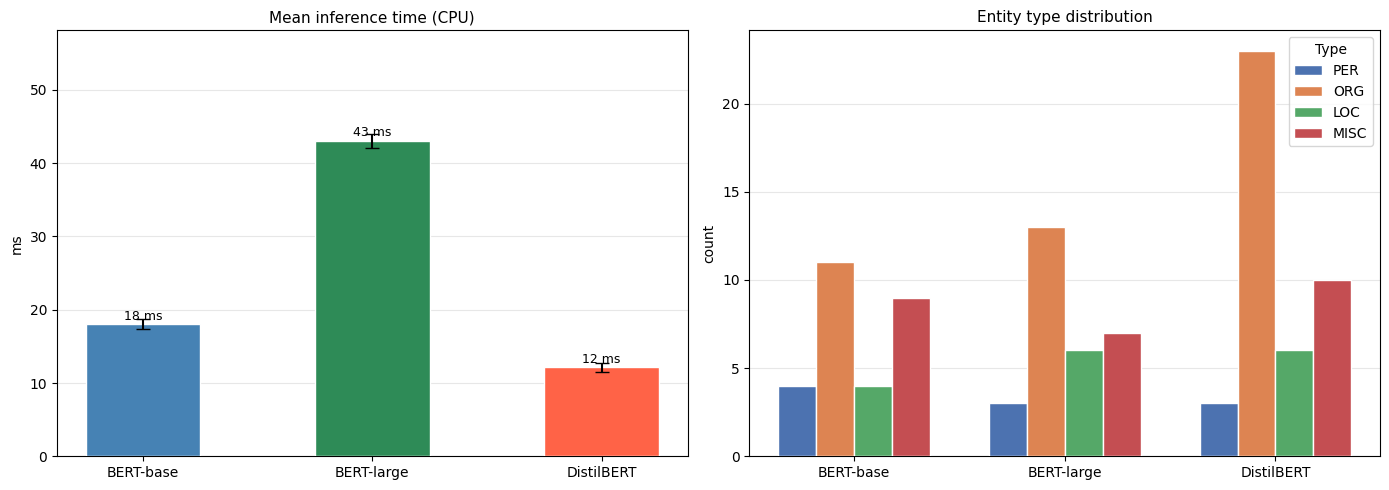

In [24]:
COLORS = {
    'BERT-base':  'steelblue',
    'BERT-large': 'seagreen',
    'DistilBERT': 'tomato',
}
TYPE_COLORS = {
    'PER':  '#4C72B0',
    'ORG':  '#DD8452',
    'LOC':  '#55A868',
    'MISC': '#C44E52',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- inference times ---
names  = list(timing.keys())
means  = [sum(v) / len(v) * 1000 for v in timing.values()]
stds   = [pd.Series(v).std() * 1000 for v in timing.values()]
colors = [COLORS[n] for n in names]

bars = ax1.bar(names, means, color=colors, edgecolor='white', width=0.5, zorder=3)
ax1.errorbar(names, means, yerr=stds, fmt='none', color='black',
             capsize=5, linewidth=1.5, zorder=4)
for bar, mean in zip(bars, means):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        mean + max(stds) * 0.2,
        f'{mean:.0f} ms',
        ha='center', va='bottom', fontsize=9,
    )
ax1.set_title('Mean inference time (CPU)', fontsize=11)
ax1.set_ylabel('ms')
ax1.set_ylim(0, max(means) * 1.35)
ax1.grid(axis='y', alpha=0.3, zorder=0)

# --- entity type distribution ---
entity_types = ['PER', 'ORG', 'LOC', 'MISC']
x          = range(len(names))
bar_width   = 0.18
offsets     = [-1.5, -0.5, 0.5, 1.5]

for i, etype in enumerate(entity_types):
    counts = [type_counts[n].get(etype, 0) for n in names]
    pos    = [xi + offsets[i] * bar_width for xi in x]
    ax2.bar(pos, counts, width=bar_width,
            color=TYPE_COLORS[etype], edgecolor='white',
            label=etype, zorder=3)

ax2.set_xticks(list(x))
ax2.set_xticklabels(names)
ax2.set_title('Entity type distribution', fontsize=11)
ax2.set_ylabel('count')
ax2.legend(title='Type')
ax2.grid(axis='y', alpha=0.3, zorder=0)

plt.tight_layout()
plt.show()

## Conclusions

The three models represent distinct points on the BERT-family accuracy-efficiency trade-off:

| Model | Params | Architecture |
|-------|--------|--------------|
| BERT-base | ~110M | 12 transformer layers, cased tokeniser |
| BERT-large | ~340M | 24 layers, ~3x the parameters of BERT-base |
| DistilBERT | ~66M | 6 layers, trained via knowledge distillation from BERT-base |

**What the results typically show:**

- **BERT-large** tends to have the highest recall, particularly on long or ambiguous entity spans (*European Organization for Nuclear Research*), at the cost of being the slowest by a wide margin (~3x vs BERT-base on CPU).
- **BERT-base** provides a solid balance: most entities are found with high confidence and inference time is moderate. It serves as a reliable general-purpose baseline.
- **DistilBERT** is the fastest (roughly 40% fewer parameters than BERT-base) with only a minor drop in accuracy on common, well-formed entities. It tends to struggle more on rare names, accented characters (*François Englert*), and edge cases, consistent with the capacity trade-off intrinsic to knowledge distillation.
- **Boundary sensitivity** degrades from large to small: BERT-large is more likely to capture the full span of a multi-token entity correctly, while DistilBERT may truncate or fragment it.
- **Confidence scores** are a practical calibration signal: low-confidence entities (below ~0.85) are worth manual review regardless of the model used, but BERT-large generally assigns higher scores to the same spans.

**Practical guidance:**

- Use DistilBERT when throughput matters and entities are common and unambiguous (e.g. batch-processing news feeds).
- Use BERT-base as a general-purpose default.
- Use BERT-large when recall on rare or complex entities is critical and latency is acceptable, or when running on GPU where the gap between model sizes narrows considerably.